In [2]:
import ast
import rich
import json

In [3]:
with open("llama_8b_lora_negoeval_plus_without_backfilling.json") as f:
    llama_8b = json.load(f)
    
with open("llama_8b_negoeval_plus_without_backfilling.json") as f:
    llama_8b_lora = json.load(f)
    
countries_list = ['Austria', 'England', 'France', 'Germany', 'Italy', 'Russia', 'Turkey']

In [4]:
def get_score_with_env(countries, prediction):
    reward_result = get_reward_score(prediction['rewards'])
    score_dict = {}
    score_dict['env'] = prediction['env_uuid']
    score_dict['countries'] = countries
    for c in countries:
        score_dict[f"{c}_taskeval_score"] = prediction[c][c.upper()][1]
        try:
            score_dict[f"{c}_negoeval_score"] = reward_result[c][1]
        except:
            return None
    return score_dict

def get_reward_score(rewards):
    result = {}
    for line in rewards.strip().splitlines():
        if not line.strip():
            continue
        key, value_str = line.split(":", 1)
        key = key.strip()
        result[key] = ast.literal_eval(value_str.strip())
    return result

def get_score_dict_from_dialogue(dialogue):
    not_found_count = 0
    score_list = []
    for a in dialogue:
        if a['intent_dialogue'] == "":
            continue
        keys = []
        for vkeys in a.keys():
            if vkeys in countries_list:
                keys.append(vkeys)
        env_score = get_score_with_env(keys, a)
        if env_score is not None:
            score_list.append(env_score)
        else:
            not_found_count += 1
            continue
    print(f"not found count: {not_found_count}")
    return score_list

In [5]:
llama_8b_lora_score = get_score_dict_from_dialogue(llama_8b_lora)
llama_8b_score = get_score_dict_from_dialogue(llama_8b)
len(llama_8b_lora_score), len(llama_8b_score)

not found count: 23
not found count: 21


(453, 452)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

def flatten_data(data_list):

    rows = []
    for entry in data_list:
        env_value = entry.get('env')
        for country in entry.get('countries', []):
            row = {
                'env': env_value,
                'country': country
            }
            taskeval_key = f'{country}_taskeval_score'
            negoeval_key = f'{country}_negoeval_score'
            if taskeval_key in entry:
                row['taskeval_score'] = entry[taskeval_key]
            else:
                row['taskeval_score'] = np.nan
            
            if negoeval_key in entry:
                row['ethos'] = entry[negoeval_key].get('ethos', np.nan)
                row['logos'] = entry[negoeval_key].get('logos', np.nan)
                row['pathos'] = entry[negoeval_key].get('pathos', np.nan)
                row['overall_score'] = entry[negoeval_key].get('overall_score', np.nan)
            else:
                row['ethos'] = np.nan
                row['logos'] = np.nan
                row['pathos'] = np.nan
                row['overall_score'] = np.nan
            
            rows.append(row)
    
    df = pd.DataFrame(rows)
    return df

def preprocess_and_correlate(df, scale_method='standard'):

    numeric_cols = ['taskeval_score', 'ethos', 'logos', 'pathos', 'overall_score']
    
    df_clean = df.dropna(subset=numeric_cols).copy()
    
    if scale_method == 'standard':
        scaler = StandardScaler()
    elif scale_method == 'minmax':
        from sklearn.preprocessing import MinMaxScaler
        scaler = MinMaxScaler()
    else:
        raise ValueError("scale_method only support 'standard' or 'minmax'")
    
    df_clean[numeric_cols] = scaler.fit_transform(df_clean[numeric_cols])
    print(df_clean)
    corr_matrix = df_clean[numeric_cols].corr(method='pearson')
    return corr_matrix, df_clean

def plot_correlation_matrix(corr_df, title="Correlation Matrix"):

    plt.figure(figsize=(6, 5))
    im = plt.imshow(corr_df, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(title)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    
    ticks = np.arange(len(corr_df.columns))
    plt.xticks(ticks, corr_df.columns, rotation=45, ha="right")
    plt.yticks(ticks, corr_df.columns)
    
    for i in range(len(corr_df.columns)):
        for j in range(len(corr_df.columns)):
            plt.text(j, i, f"{corr_df.iloc[i, j]:.2f}",
                     ha="center", va="center", color="black")
    
    plt.tight_layout()
    plt.show()

def plot(data_list, model):
    
    df = flatten_data(data_list)

    corr_matrix, df_clean = preprocess_and_correlate(df, scale_method='minmax')

    print(df_clean.head(), "\n")

    print("Correlation Matrix:")
    print(corr_matrix, "\n")

    plot_correlation_matrix(corr_matrix, title=f"{model.capitalize()} Correlation Matrix (Standard Scaled)")

                            env  country  taskeval_score     ethos     logos  \
0    01JN071GW86D8ZP9WR6HWEJE7B  England        0.542565  1.000000  0.714286   
1    01JN071GW86D8ZP9WR6HWEJE7B  Germany        0.498692  0.428571  0.285714   
2    01JN071GPVSAP2V64SGVMJZX1K  Germany        0.429311  0.714286  0.571429   
3    01JN071GPVSAP2V64SGVMJZX1K    Italy        0.728002  0.714286  0.571429   
4    01JN071F0TP317M7YHKMR8DF90  Austria        0.504852  1.000000  0.714286   
..                          ...      ...             ...       ...       ...   
899  01JN071HAVSR48HRX7D5STHYV0   France        0.425908  1.000000  0.714286   
900  01JN071GANW1S5SXW04FJJ7Z13   Russia        0.535362  0.714286  0.428571   
901  01JN071GANW1S5SXW04FJJ7Z13   Turkey        0.648505  1.000000  1.000000   
902  01JN071ECSPGGMJT4YXRS95DNZ  Austria        0.503510  1.000000  0.857143   
903  01JN071ECSPGGMJT4YXRS95DNZ    Italy        0.530181  0.857143  0.571429   

     pathos  overall_score  
0     0.87

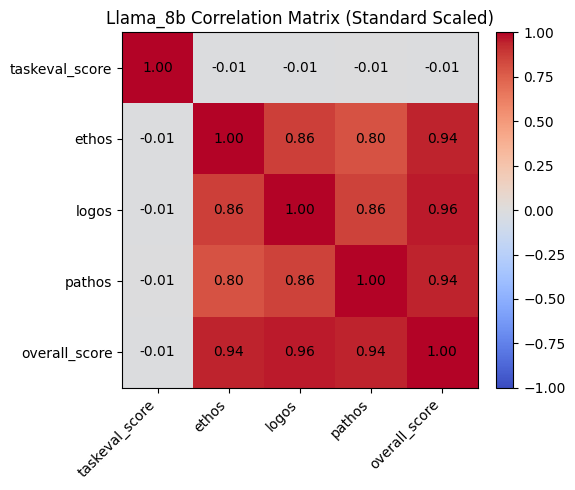

In [7]:
plot(llama_8b_score, "llama_8b")

                            env  country  taskeval_score  ethos     logos  \
0    01JN071H84NFF9HWGRNQ5FN9S2   Turkey        0.547600    0.2  0.142857   
1    01JN071H84NFF9HWGRNQ5FN9S2    Italy        0.397357    1.0  0.857143   
2    01JN071DSNTS2AM1HYSHS0NSHG  England        0.503138    1.0  0.857143   
3    01JN071DSNTS2AM1HYSHS0NSHG   France        0.372951    1.0  0.857143   
4    01JN071CYEJKPP0JX1NWM89PVS   Turkey        0.525863    0.8  0.857143   
..                          ...      ...             ...    ...       ...   
901  01JN071FH3GKGXGW0MFH7YR3R8   Russia        0.511260    1.0  0.857143   
902  01JN071FHM54P5F8H8YJA7XPTN  Germany        0.431703    0.8  0.857143   
903  01JN071FHM54P5F8H8YJA7XPTN   France        0.388958    0.6  0.428571   
904  01JN071GHJQB4547E3G78BN15C  England        0.488489    0.2  0.428571   
905  01JN071GHJQB4547E3G78BN15C   Russia        0.533965    0.8  0.857143   

       pathos  overall_score  
0    0.285714       0.210526  
1    0.857143

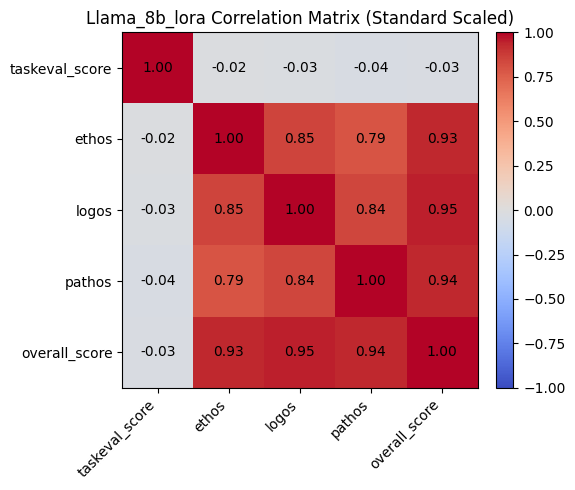

In [8]:
plot(llama_8b_lora_score, "llama_8b_lora")